<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

from scipy.integrate import odeint

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imputation Done!!!


# Define the SEIR model

In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, alpha, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    D = state[4*n:5*n]
    C = state[5*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dD = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma * E[i]
        dI[i] =  sigma * E[i] - (gamma + alpha) * I[i]
        dR[i] =  gamma * I[i]
        dD[i] = alpha * I[i]
        dC[i] = sigma * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dD.flatten(), dC.flatten()])


# Define Parameters

In [4]:
1/8.5 *7 

0.8235294117647058

In [5]:
n_regions = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

# N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N=[1000000, 960000, 745000]
N = np.array([110000, 440000, 680000])

## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = 1/8.5 *7       # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/13 *7      # 1/infectious period (Ebola: ~7 days)
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1 #0.8  # Proportion of cases reported

## Get initials
# guinea = [N[0]-1000, 0, 1000, 0, 1000]
# lib = [N[1]-100, 0, 100, 0, 100]
# sir = [N[2]-100, 0, 100, 0, 100]

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
D0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-10, N[1]-10, N[2]-10])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten(), C0.flatten()])


# Solve the ODEs

In [6]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma,alpha, N))

## Get the New Infections and Deaths

In [7]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
D_total = sol[:, 4*n:5*n]
C_total = sol[:, 5*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])
Deaths = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]
    
    ## get new deaths
    for i in (range(len(D_total))):

        if (i+1 == len(D_total)):
            new_deaths = [0.0,0.0,0.0]
            Deaths[i, j] = new_deaths[j]
        else:
            new_deaths = D_total[i+1] - D_total[i]
            Deaths[i+1, j] = new_deaths[j]

## Show New infections

In [8]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.28323595e+01, 1.56123126e+01, 1.41974855e+01],
       [2.19574638e+01, 3.30422897e+01, 2.71525094e+01],
       [3.50871034e+01, 6.47774992e+01, 4.82472635e+01],
       [5.57896188e+01, 1.26529159e+02, 8.53806032e+01],
       [8.86238686e+01, 2.46985044e+02, 1.51031447e+02],
       [1.40640477e+02, 4.81639582e+02, 2.67071434e+02],
       [2.22838683e+02, 9.37442726e+02, 4.71992520e+02],
       [3.52205769e+02, 1.81784409e+03, 8.33292537e+02],
       [5.54506832e+02, 3.49988962e+03, 1.46850117e+03],
       [8.67669634e+02, 6.64645342e+03, 2.57969552e+03],
       [1.34477751e+03, 1.23004769e+04, 4.50649732e+03],
       [2.05375582e+03, 2.17225343e+04, 7.79637106e+03],
       [3.06732915e+03, 3.54089744e+04, 1.32647193e+04],
       [4.43288709e+03, 5.09737867e+04, 2.19436357e+04],
       [6.11413419e+03, 6.20630264e+04, 3.46820298e+04],
       [7.91919341e+03, 6.25395622e+04, 5.11012454e+04],
       [9.47814360e+03, 5.28198

In [9]:
Deaths

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.88941469e+00, 4.15110575e+00, 4.01869441e+00],
       [5.76448369e+00, 7.51229851e+00, 6.59955359e+00],
       [9.12062506e+00, 1.46219510e+01, 1.16264957e+01],
       [1.44957259e+01, 2.85557521e+01, 2.05661327e+01],
       [2.30356422e+01, 5.57571445e+01, 3.63831814e+01],
       [3.65806648e+01, 1.08795931e+02, 6.43504839e+01],
       [5.80225679e+01, 2.12003909e+02, 1.13768420e+02],
       [9.18628466e+01, 4.12045432e+02, 2.00988333e+02],
       [1.45015787e+02, 7.96817391e+02, 3.54612298e+02],
       [2.27875071e+02, 1.52606933e+03, 6.24222764e+02],
       [3.55518933e+02, 2.86988186e+03, 1.09439901e+03],
       [5.48541853e+02, 5.21960579e+03, 1.90528953e+03],
       [8.32183746e+02, 8.95782423e+03, 3.27706658e+03],
       [1.23115932e+03, 1.40155720e+04, 5.52211560e+03],
       [1.75677054e+03, 1.92558210e+04, 8.99735998e+03],
       [2.38551928e+03, 2.26250230e+04, 1.39089187e+04],
       [3.03853099e+03, 2.26602

## Add Noise

In [10]:
## Function to add noise
def Add_noise(data, reporting_rate):
    observed_cases = []
    for i in range(len(np.array(data))):
        case = []
        for t in range(len(np.array(data)[i])):
            mean_cases = reporting_rate * np.array(data)[i][t]

            # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
            p = phi / (phi + mean_cases)
            case.append(np.random.negative_binomial(phi, p))
        observed_cases.append(case)
    return np.array(observed_cases)


In [11]:
observed_cases = Add_noise(Infections, reporting_rate= reporting_rate)
observed_deaths = Add_noise(Deaths, reporting_rate= reporting_rate)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])
d = pd.DataFrame(observed_deaths, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [12]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'D_Guinea': D_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],
    'Guinea_New_Deaths': Deaths[:, 0],
    'Guinea_Death_Noise' : d['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'D_Liberia': D_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],
    'Liberia_New_Deaths': Deaths[:, 1],
    'Liberia_Death_Noise' : d['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'D_SierraLeone': D_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
    'SierraLeone_New_Deaths': Deaths[:, 2],
    'SierraLeone_Death_Noise' : d['Sierra Leone'],
}

raw = pd.DataFrame(data)
# df.to_csv('synthetic_ebola_dataset_with_death.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,D_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,...,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,D_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise,SierraLeone_New_Deaths,SierraLeone_Death_Noise
0,2013-12-28,0,109990.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0,...,679990.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0
1,2013-12-29,1,109966.668108,20.499532,12.959230,5.983715,3.889415,12.832360,12.832360,18,...,679961.870135,23.932380,13.996184,6.182607,4.018694,14.197485,14.197485,12,4.018694,4
2,2013-12-30,2,109932.097122,33.113055,20.283774,14.852151,9.653898,34.789823,21.957464,18,...,679915.677419,42.972586,24.395981,16.335766,10.618248,41.349995,27.152509,43,6.599554,6
3,2013-12-31,3,109877.420754,52.702319,32.218521,28.883882,18.774523,69.876927,35.087103,15,...,679834.306910,76.095831,43.129832,34.222683,22.244744,89.597258,48.247263,37,11.626496,10
4,2014-01-01,4,109790.577656,83.755798,51.211297,51.184999,33.270249,125.666546,55.789619,48,...,679690.394295,134.627843,76.304098,65.862887,42.810876,174.977862,85.380603,118,20.566133,22


# Plot the results

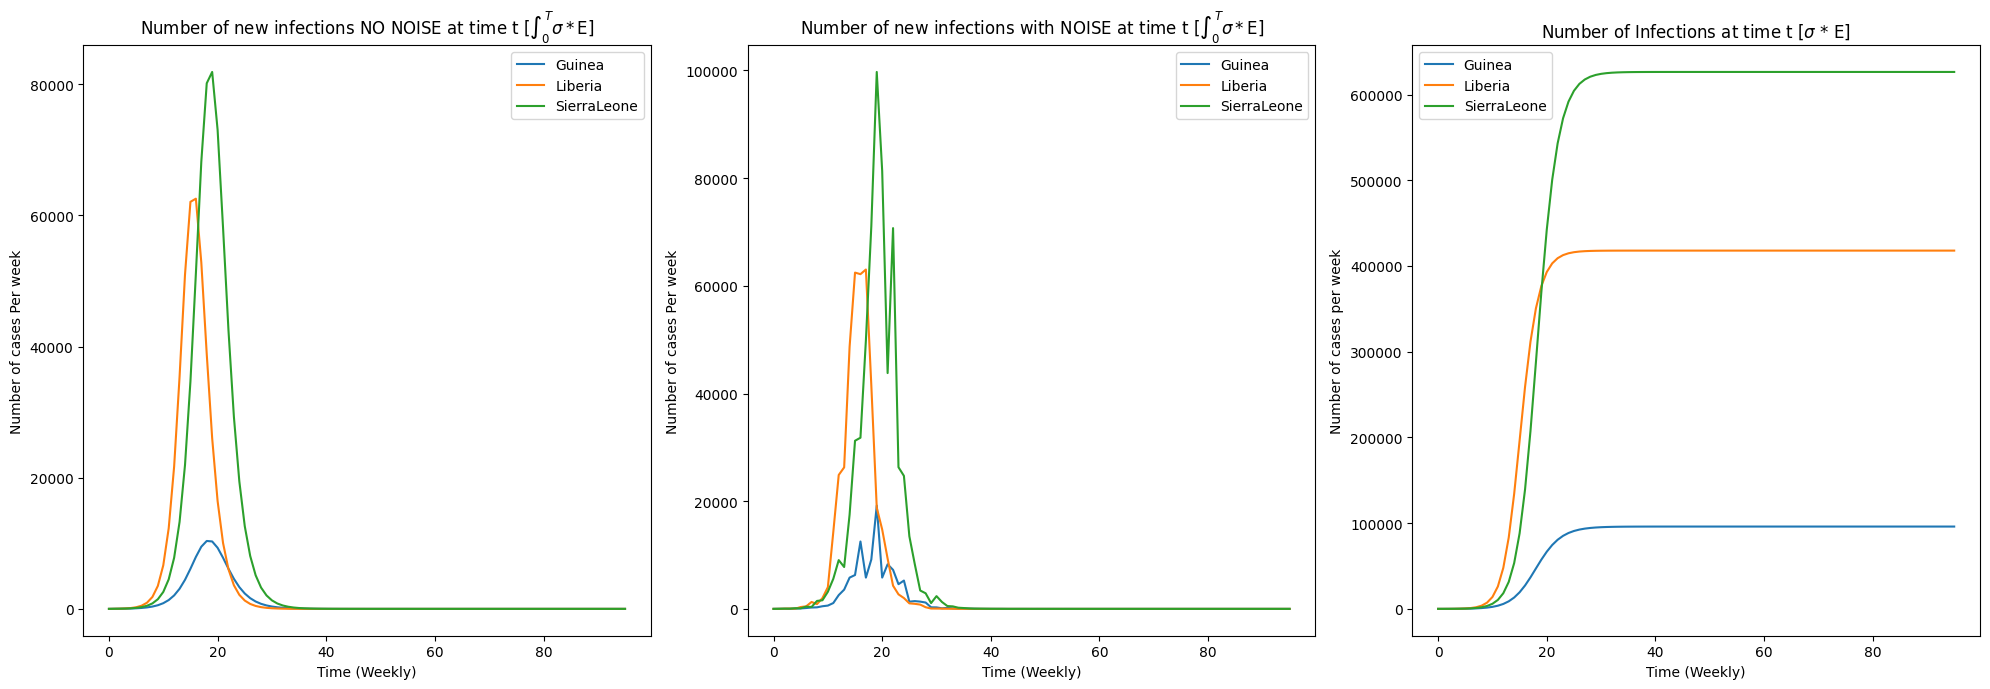

In [13]:
fig, ax = plt.subplots(1,3, figsize = (20,7))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw[f'C_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

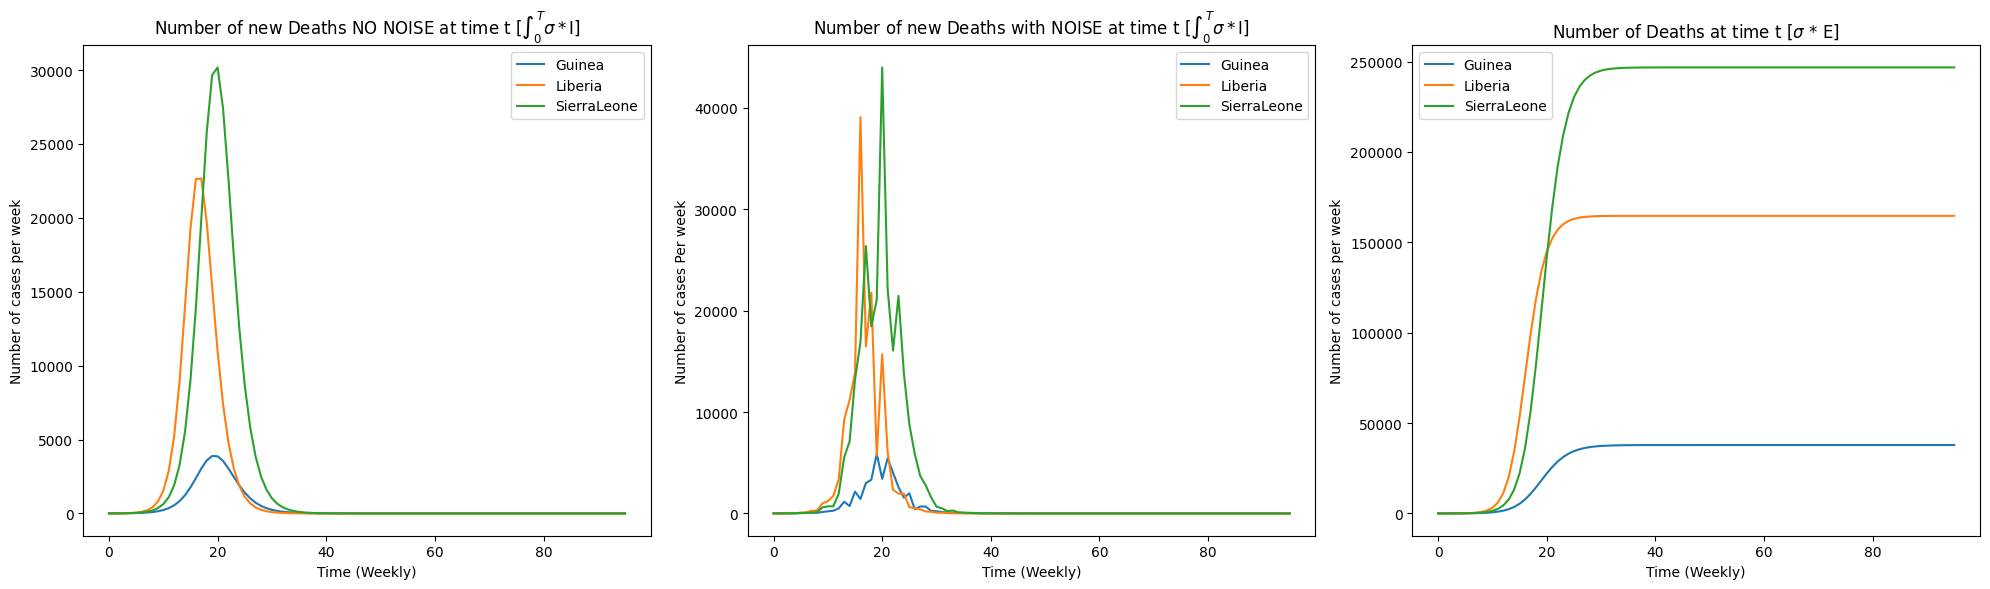

In [14]:
fig, ax = plt.subplots(1,3, figsize = (20,6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_Deaths'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new Deaths NO NOISE at time t $[\int_0^T \sigma*$I]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases per week')

    ax[1].plot(raw[f'{countries[i]}_Death_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new Deaths with NOISE at time t $[\int_0^T \sigma*$I]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw[f'D_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Deaths at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

In [15]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = True):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Recovered', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

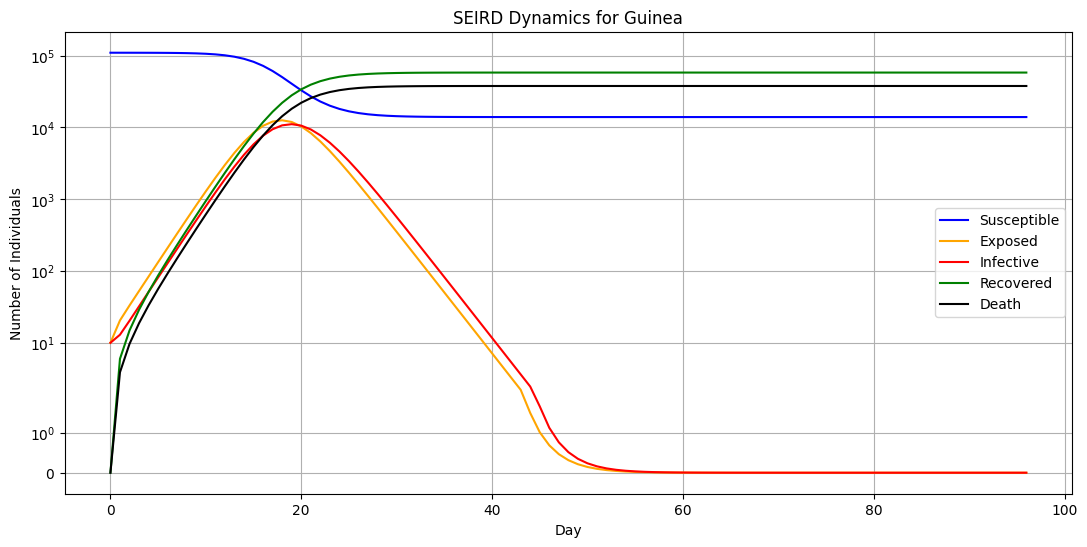

In [16]:
plot_SEIR(raw, 'Guinea', Death=True)

# Aggregate the Data from daily cases to weekly cases

## Aggregate the Data

In [17]:
# def Aggregate_data(data):
#     # Convert the 'time' column to datetime format, assuming it represents days since 2014-01-01
#     # data["time"] = pd.Timestamp("2014-01-01") + pd.to_timedelta(data["time"], unit="D")

#     ## get patches
#     patch_names = ["Guinea", "Liberia", "Sierra Leone"]
#     n_patches = len(patch_names)

#     ## Set the start date and end of the date
#     start_date =  data["time"].min()
#     end_date = data["time"].max()
#     weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
#     T = len(weeks)

#     ## Create an empty array to store observed cases
#     I_obs = np.zeros((T, n_patches))

#     ## Fill the observed cases array with weekly data for each patch
#     for i, country in enumerate(patch_names):
#         country_data = data[data["country"] == country]
#         weekly_cases = country_data.groupby(pd.Grouper(key="time", freq="W-MON"))['cases'].sum()
#         # weekly_cases.index = pd.to_datetime(weekly_cases.index)
#         weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
#         I_obs[:, i] = weekly_cases.values

#     ## Create a DataFrame for plotting
#     time = np.arange(1, T + 1)
#     Cases = pd.DataFrame(I_obs, columns=patch_names)
#     Cases["Time"] = time
#     Cases["Week"] = weeks[:].strftime("%Y-%m-%d")

#     # Melt the DataFrame for easier plotting
#     Cases = Cases.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

#     return Cases

In [18]:
# df2 = raw[['time','Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']]
# # weekly_cases = df2.groupby(pd.Grouper(key="time", freq="W-MON"))[['Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']].sum()

## Add the noise to the data

In [19]:
def add_nb_noise(series, dispersion=10):
    # Ensure the series contains only numeric values
    series = pd.to_numeric(series, errors='coerce')  # Convert non-numeric to NaN
    series = series.fillna(0)  # Replace NaN with 0 (or handle it as needed)

    mu = series.values
    r = dispersion
    p = r / (r + mu)  # NB2 parameterization

    noisy = np.random.negative_binomial(n=r, p=p)
    return pd.Series(noisy, index=series.index)


In [20]:
# weekly_cases = weekly_cases.reset_index(drop=True)

# # Apply to all three columns
# noisy_cases = weekly_cases.copy()
# for col in noisy_cases.columns:
#     noisy_cases[col] = add_nb_noise(noisy_cases[col], dispersion=10)

# noisy_cases.head()

## Plot them

In [21]:
# fig, ax = plt.subplots(1, 2, figsize=(18, 7))
# ct =['Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']

# # Plot each patch separately
# for patch in ct:
#     ax[0].plot(raw['Day'], raw[patch], label=patch)
# ax[0].set_title("Weekly New Ebola Cases (Noised Before Aggregation)")
# ax[0].set_xlabel("Week")
# ax[0].set_ylabel("Number of Cases")
# ax[0].legend(title="Patches")

# for patch in ct:
#     ax[1].plot(noisy_cases.index, noisy_cases[patch], label=patch)
# ax[1].set_title("Weekly New Ebola Cases  (Noised After aggregation)")
# ax[1].set_xlabel("Week")
# ax[1].set_ylabel("Number of Cases")
# ax[1].legend(title="Patches")
# # plt.grid(True)
# # plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
# plt.show()

# Create a function to plot Posterior for Parameters

In [22]:
import math

def plot_posterior_kde_grid(fit:any, parameters: list, n_rows: int, n_cols: int, true_values: dict = None):
    """
    Plot KDEs of posterior samples for given parameters from a CmdStanMCMC fit.

    Args:
        fit (CmdStanMCMC): The fitted model.
        parameters (list of str): Names of parameters to plot.
        n_rows (int): Number of subplot rows.
        n_cols (int): Number of subplot columns.
        true_values (dict, optional): Dict mapping param names to true values for reference lines.
    """
    posterior_samples = fit.draws_pd()
    
    # Dynamically calculate the number of rows
    n_params = len(parameters)
    n_rows = math.ceil(n_params / n_cols)

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    ax = ax.flatten()  # flatten axes for easy indexing

    for i, param in enumerate(parameters):
        if param in posterior_samples.columns:
            sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])
            if true_values and param in true_values:
                ax[i].axvline(x=true_values[param], color='r', linestyle='--', label='True value')
                ax[i].legend()
            ax[i].set_xlabel(param)
            ax[i].set_ylabel('Density')
            ax[i].set_title(f'Posterior of {param}')
        else:
            ax[i].text(0.5, 0.5, f"{param} not found", ha='center', va='center')
            ax[i].axis('off')

    # Hide unused axes
    for j in range(len(parameters), len(ax)):
        ax[j].axis('off')

    plt.tight_layout()
    plt.show()


# Fit the Model to daily cases


In [56]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

# N = np.array([11.5e6, 4.5e6, 6.8e6]) 
N = np.array([110000, 440000, 680000]) 
# N=np.array([2e6, 1.5e6, 1e6])
# Set the population size
# N = n[0] #763

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = 1/8.5 *7       # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/13 *7      # 1/infectious period (Ebola: ~7 days)
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0
r0 = [0, 0, 0]
c0 = [0, 0, 0]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [59]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma,
    'gamma_value': gamma,
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma,
    'gamma_value': gamma,
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma,
    'gamma_value': gamma,
    "reporting_rate": reporting_rate
}

seir_incidence_model = CmdStanModel(stan_file = 'stan files/guinea.stan')
seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/lib.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/sierra.stan')

In [ ]:
fit_seir_incidence_model = seir_incidence_model.sample(data = seir_data1,
                                                    #    iter_warmup= 500,
                                                       iter_sampling = 1000,
                                                       parallel_chains=True,
                                                       chains = 4)

chain 1 |          | 00:00 Status


chain 1 |████████▋ | 03:26 Iteration: 1600 / 2000 [ 80%]  (Sampling)

In [ ]:
fit2 = seir_incidence_model1.sample(data = seir_data2,
                                    # iter_warmup= 500,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4)

chain 1 |          | 00:00 Status


chain 1 |▍         | 00:15 Status
chain 1 |█▎        | 01:00 Iteration:  100 / 2000 [  5%]  (Warmup)
chain 1 |█▊        | 01:20 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 01:38 Iteration:  300 / 2000 [ 15%]  (Warmup)
chain 1 |██▋       | 01:59 Iteration:  400 / 2000 [ 20%]  (Warmup)
chain 1 |███▋      | 02:23 Iteration:  600 / 2000 [ 30%]  (Warmup)
chain 1 |████      | 02:39 Iteration:  700 / 2000 [ 35%]  (Warmup)
chain 1 |████▌     | 02:45 Iteration:  800 / 2000 [ 40%]  (Warmup)
chain 1 |█████     | 03:05 Iteration:  900 / 2000 [ 45%]  (Warmup)

chain 1 |█████▉    | 03:28 Iteration: 1001 / 2000 [ 50%]  (Sampling)
chain 1 |██████▎   | 03:49 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 04:10 Iteration: 1200 / 2000 [ 60%]  (Sampling)
chain 1 |███████▎  | 04:33 Iteration: 1300 / 2000 [ 65%]  (Sampling)
chain 1 |███████▋  | 04:54 Iteration: 1400 / 2000 [ 70%]  (Sampling)
chain 1 |████████▏ | 05:15 Iteration: 1500 / 2

In [ ]:
fit3 = seir_incidence_model2.sample(data = seir_data3,
                                    # iter_warmup= 500,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4)

chain 1 |          | 00:00 Status





chain 1 |▍         | 00:27 Status
chain 1 |█▎        | 01:56 Iteration:  100 / 2000 [  5%]  (Warmup)
chain 1 |█▊        | 02:25 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:51 Iteration:  300 / 2000 [ 15%]  (Warmup)
chain 1 |██▋       | 03:19 Iteration:  400 / 2000 [ 20%]  (Warmup)
chain 1 |███▏      | 03:45 Iteration:  500 / 2000 [ 25%]  (Warmup)
chain 1 |███▋      | 04:12 Iteration:  600 / 2000 [ 30%]  (Warmup)
chain 1 |████      | 04:36 Iteration:  700 / 2000 [ 35%]  (Warmup)
chain 1 |████▌     | 05:02 Iteration:  800 / 2000 [ 40%]  (Warmup)
chain 1 |█████▍    | 05:32 Iteration: 1000 / 2000 [ 50%]  (Warmup)
chain 1 |█████▉    | 06:16 Iteration: 1001 / 2000 [ 50%]  (Sampling)
chain 1 |██████▎   | 06:53 Iteration: 1100 / 2000 [ 55%]  (Sampling)

chain 1 |██████▊   | 07:24 Iteration: 1200 / 2000 [ 60%]  (Sampling)
chain 1 |███████▎  | 07:52 Iteration: 1300 / 2000 [ 65%]  (Sampling)
chain 1 |███████▋  | 08:20 Iteration: 1400 / 2000 [ 70%]  (Sampling)
chain 1 |███████

In [ ]:
seir_incidence_summary = fit_seir_incidence_model.summary()
seir_incidence_summary.filter(items=("sigma", "beta", "recovery_time", "gamma", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.475673,0.004889,0.142129,0.129476,0.217439,0.477127,0.711746,901.762,455.592,1.00156
beta,1.613380,0.004886,0.163297,0.147185,1.379900,1.593970,1.920910,1111.280,1231.230,1.00352
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gamma,0.686040,0.005111,0.164536,0.152950,0.452350,0.668289,0.985533,901.497,822.889,1.00134
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,6.824180,0.052037,1.853450,1.788230,4.131710,6.633800,10.090300,1391.380,1554.480,1.00180
phi_inv,0.157856,0.001137,0.045124,0.040778,0.099105,0.150744,0.242031,1391.390,1554.480,1.00165


In [ ]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "recovery_time", "gamma", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.605049,0.008411,0.164726,0.133980,0.238035,0.614013,0.855417,503.146,268.672,1.01067
beta,2.112230,0.004987,0.182220,0.179543,1.845850,2.091330,2.431150,1354.270,1861.060,1.00479
recovery_time,1.853280,0.054980,0.837975,0.342985,1.169020,1.628620,4.201060,503.148,268.672,1.01067
gamma,1.038840,0.012736,0.332694,0.298020,0.590343,0.991915,1.626600,519.989,358.831,1.00491
incubation_period,1.055450,0.015322,0.316656,0.302443,0.614780,1.008150,1.693930,519.992,358.831,1.00491
R0,2.250160,0.029743,0.750655,0.803006,1.170270,2.141700,3.589510,690.577,1419.220,1.00231
phi,5.770450,0.044353,1.625750,1.560680,3.391730,5.610080,8.758040,1394.230,1628.130,1.00249
phi_inv,0.187880,0.001531,0.056314,0.048196,0.114181,0.178250,0.294835,1394.260,1628.130,1.00282


In [ ]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "recovery_time", "gamma", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.804799,0.004316,0.138390,0.122458,0.612880,0.786890,1.052500,1253.53,845.508,1.00220
beta,2.029380,0.008035,0.235832,0.197571,1.732540,1.985600,2.485990,1153.54,834.408,1.00170
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gamma,1.172560,0.006998,0.288822,0.260609,0.793531,1.124650,1.697880,1754.09,1997.060,1.00197
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,9.727460,0.053743,2.429430,2.347560,6.179400,9.417010,14.095800,2002.18,2289.740,1.00156
phi_inv,0.109406,0.000656,0.028178,0.026303,0.070943,0.106191,0.161828,2002.16,2289.740,1.00184


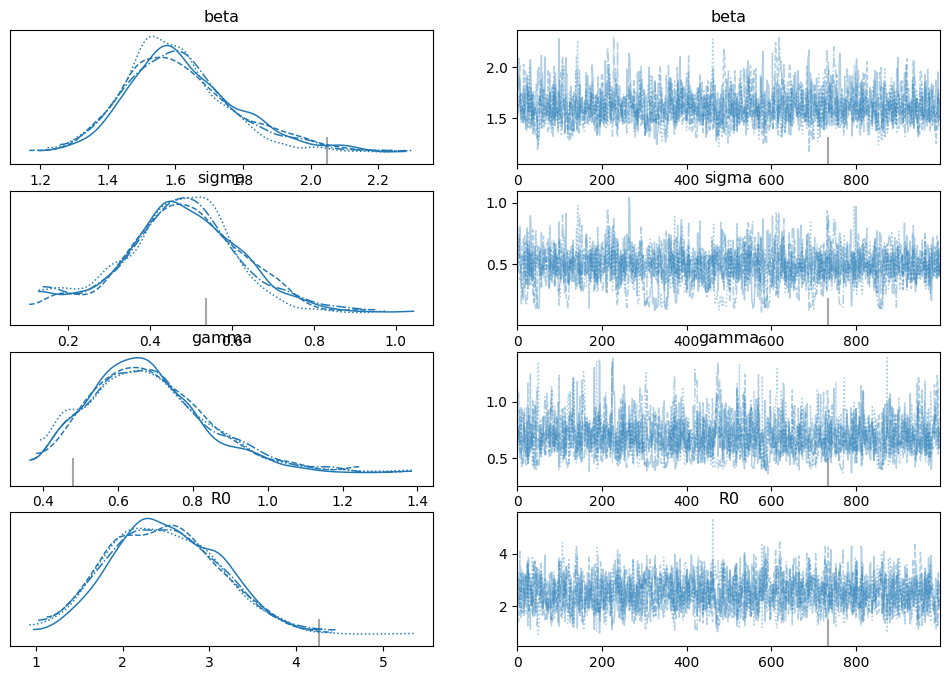

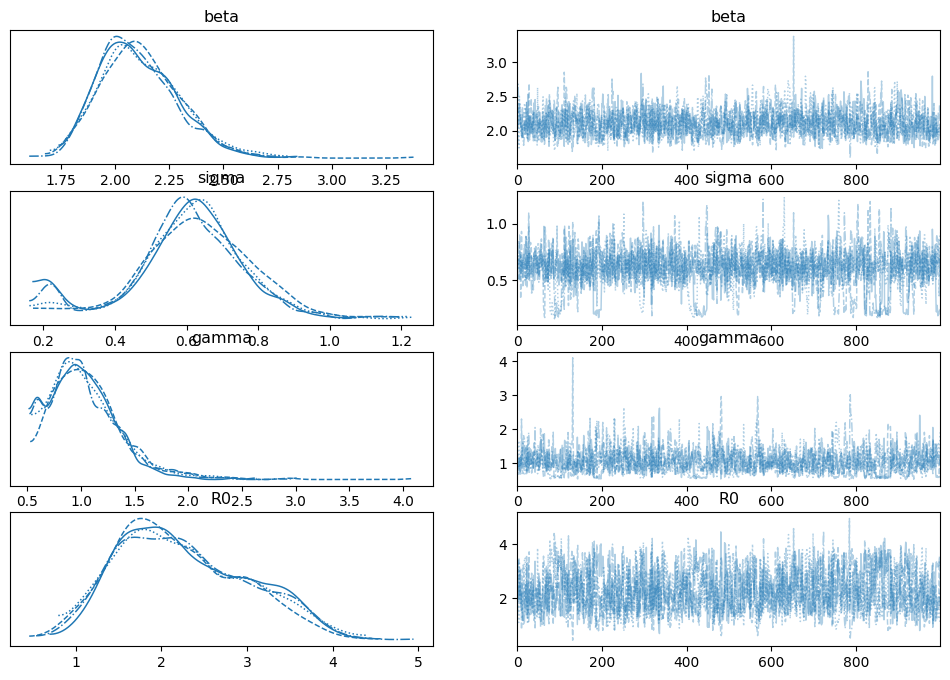

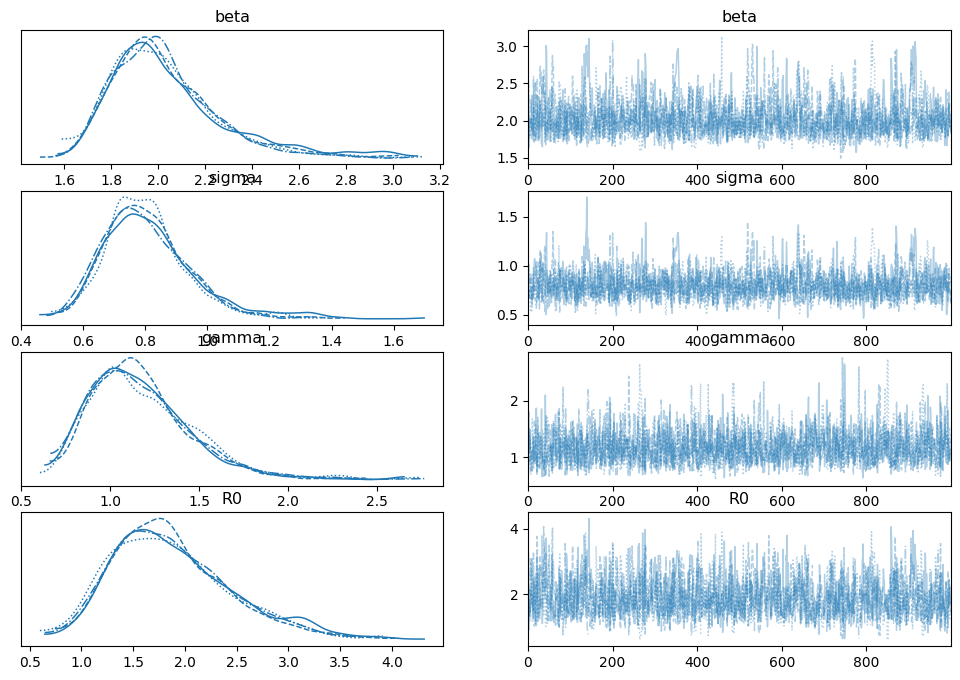

In [ ]:
## trace plots
az.plot_trace(fit_seir_incidence_model, var_names=["beta", "sigma", "gamma", "R0"])
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"])
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

# Posterior Predictive Checks

In [ ]:
seir_incidence_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[2],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[3],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[4],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[5],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[93],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[94],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pred_incidence[95],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


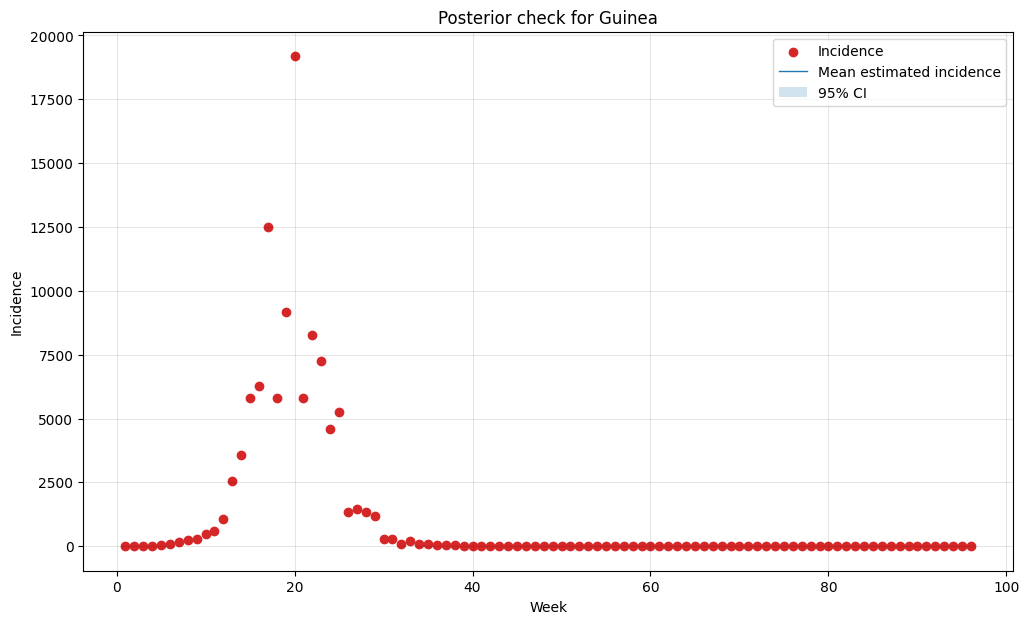

In [ ]:
post_pred = pd.DataFrame(seir_incidence_summary.filter(like="pred_incidence", axis=0))
post_pred["t"] = range(1, T+1)
post_pred["incidence"] = list(cases1)
post_pred = post_pred.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred.index, y = post_pred.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred.index, y1 = post_pred['5%'], y2 = post_pred['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

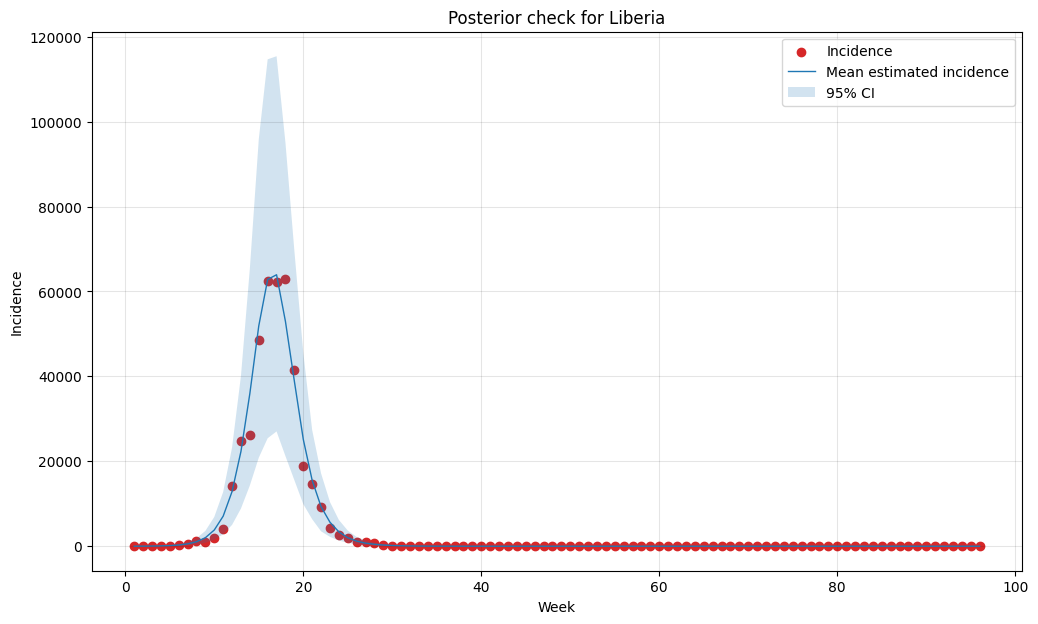

In [ ]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

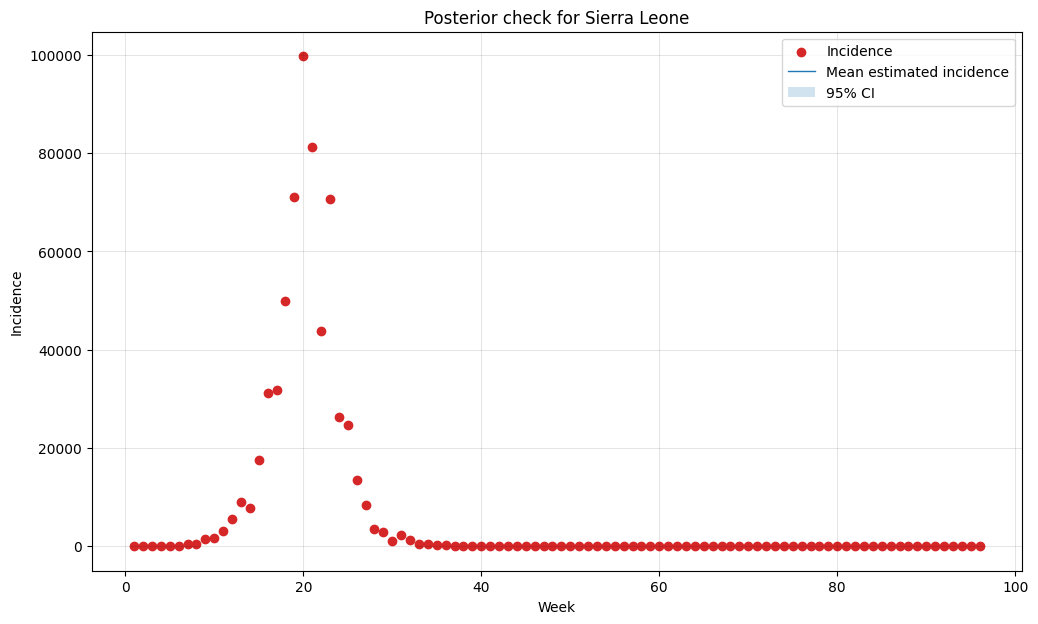

In [ ]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [ ]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = 1/8.5 *7       # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/13 *7      # 1/infectious period (Ebola: ~7 days)
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec,
    'incubation_period': incu}

t2 = {'beta':beta[1],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec,
    'incubation_period': incu}

t3 = {'beta':beta[1],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec,
    'incubation_period': incu}

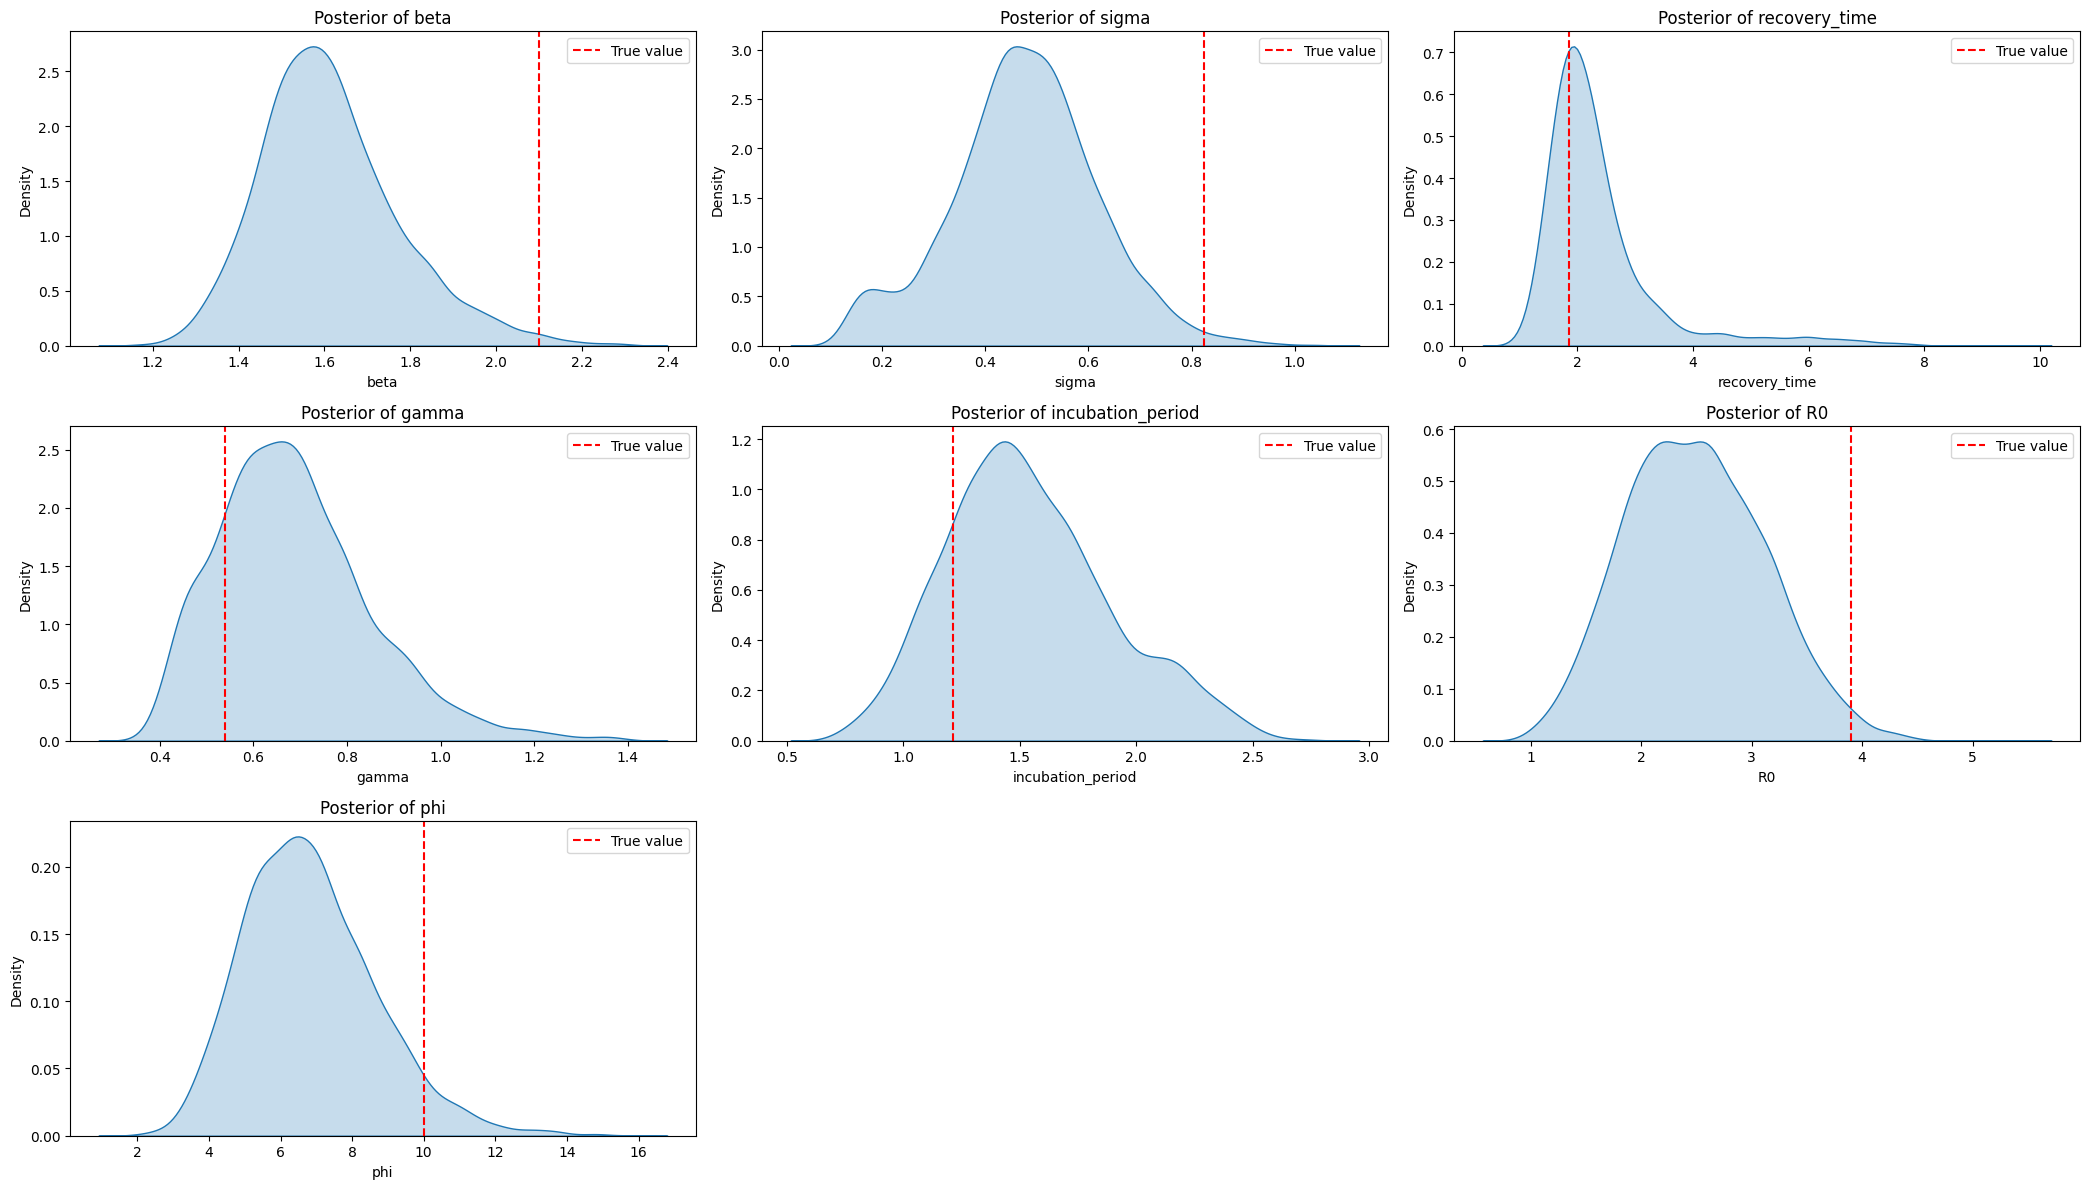

In [ ]:
plot_posterior_kde_grid(fit_seir_incidence_model, parameters1, 2,3,t1)

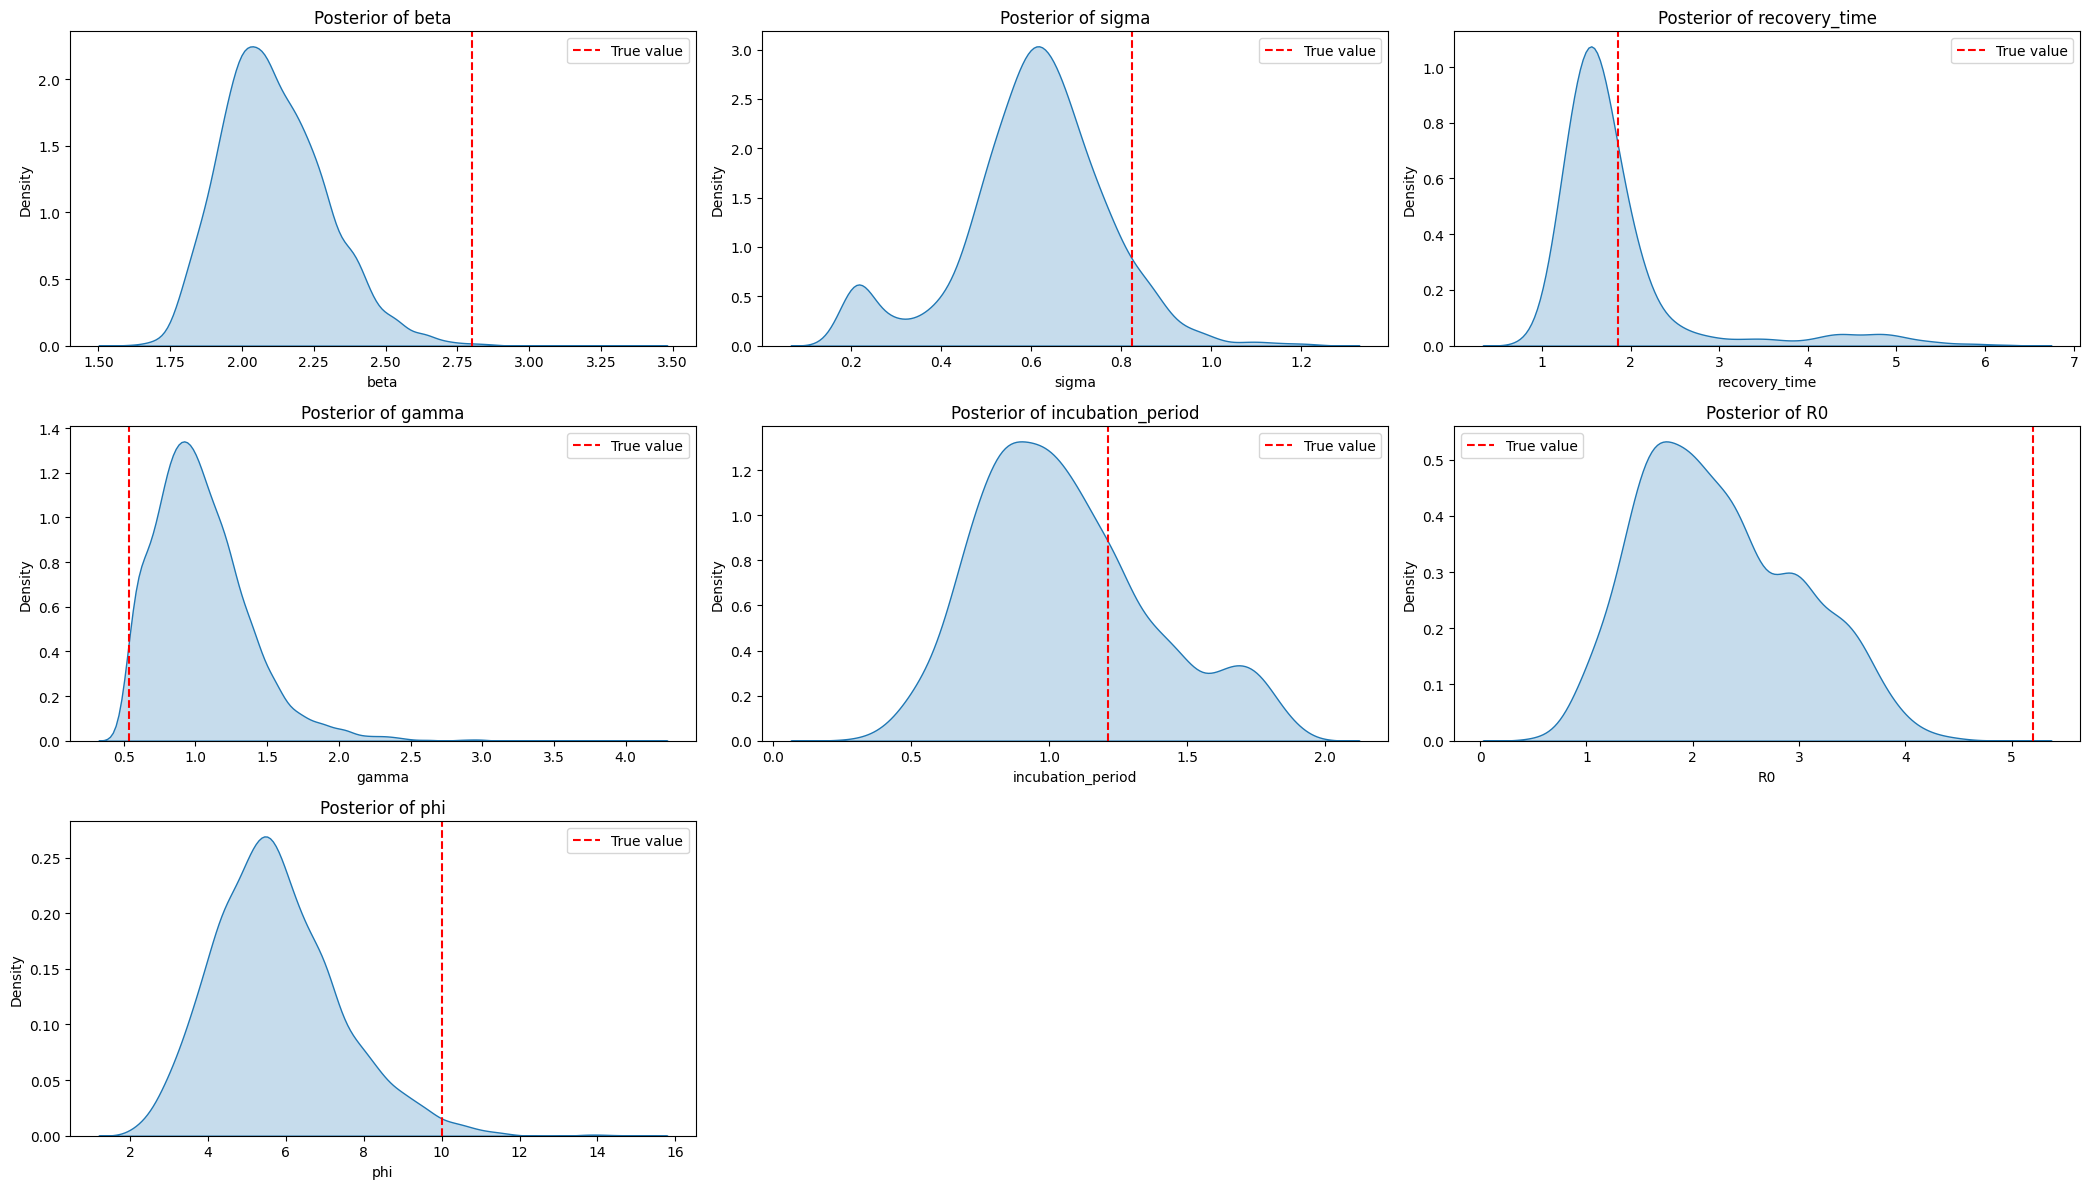

In [ ]:
plot_posterior_kde_grid(fit2, parameters1, 2,3,t2)

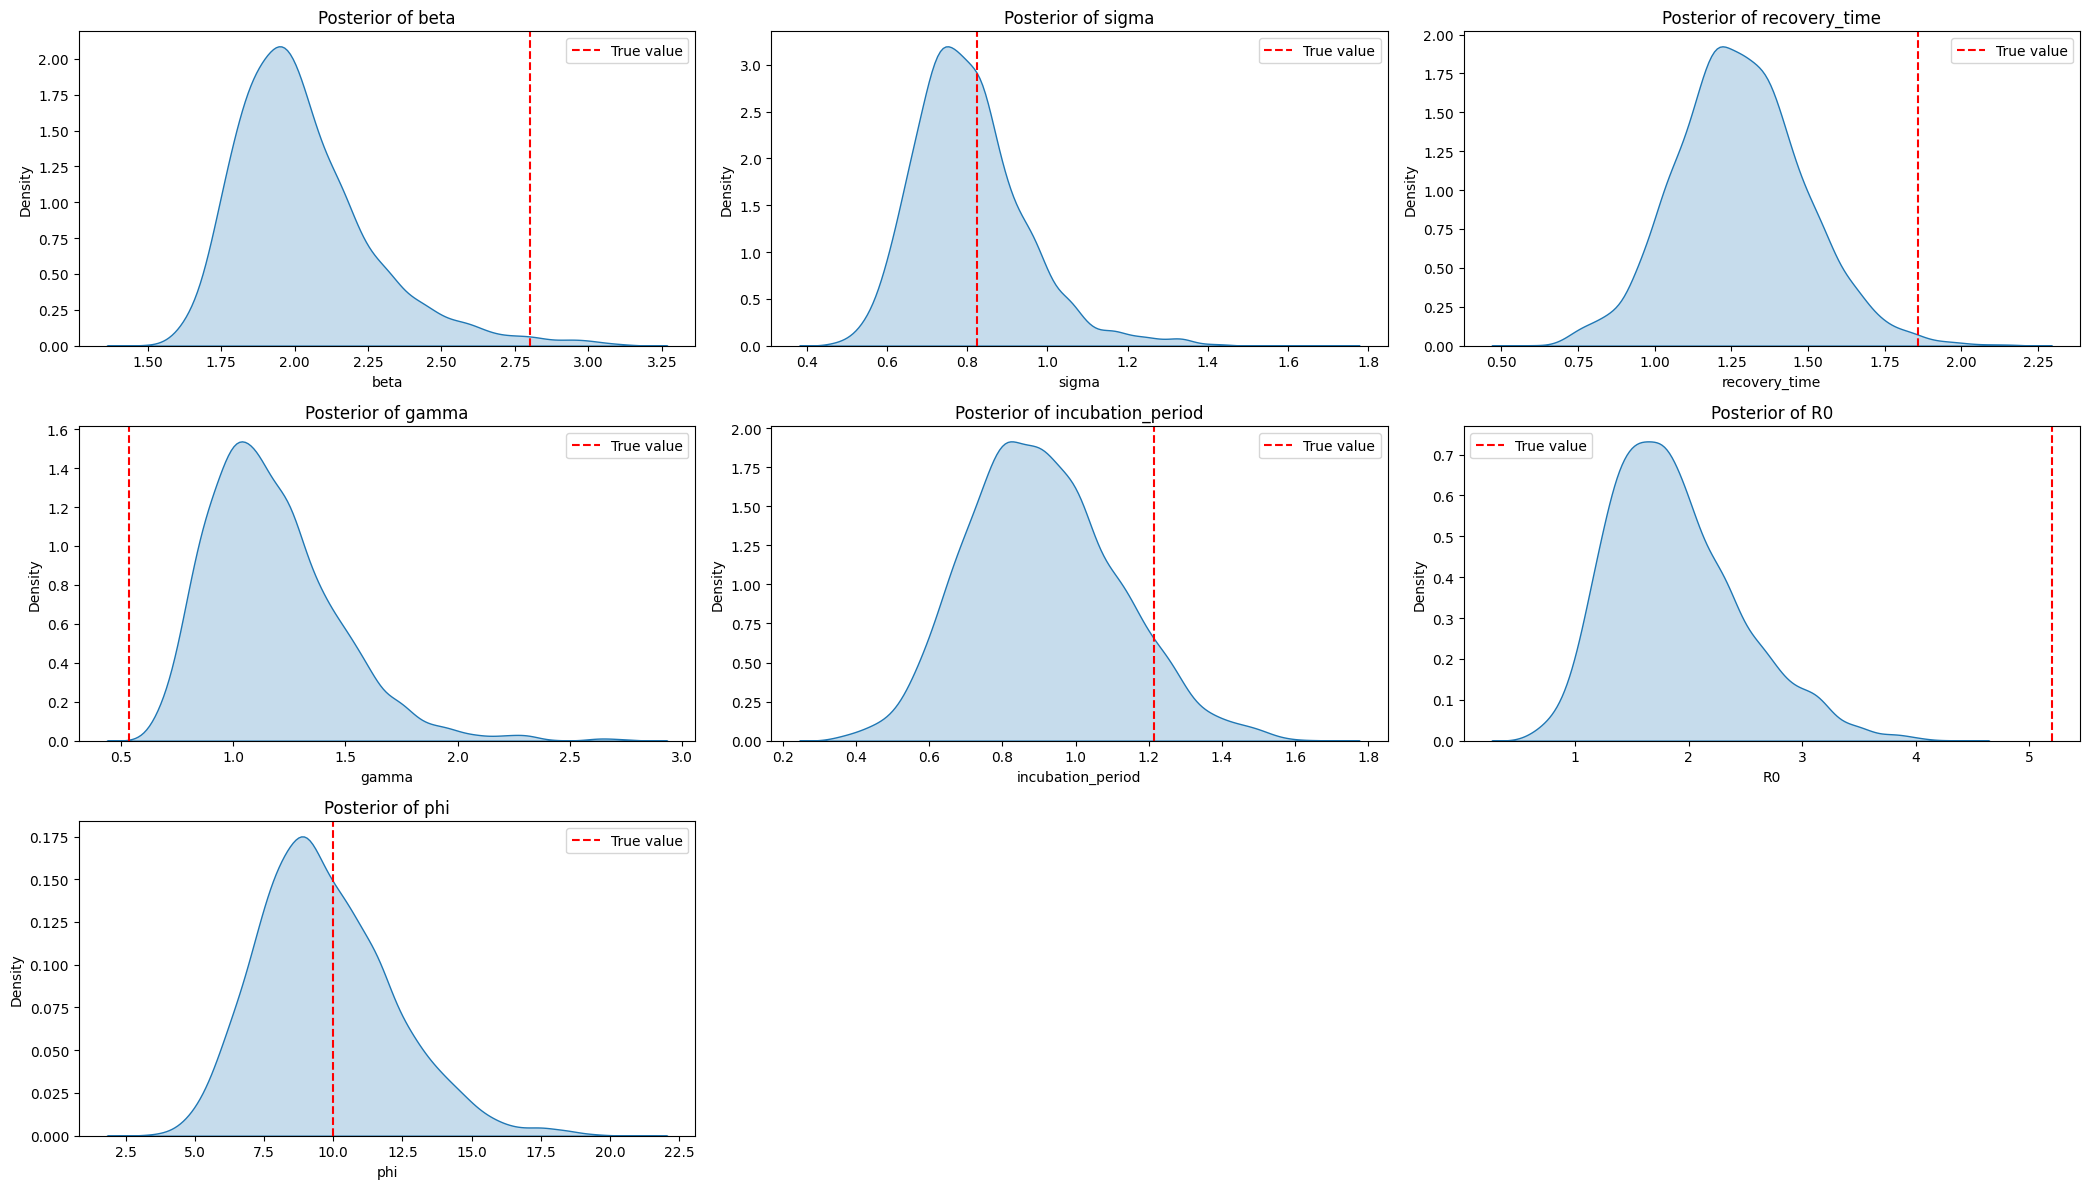

In [ ]:
plot_posterior_kde_grid(fit3, parameters1, 2,3,t3)

## Plot SEIR Compartments

In [ ]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [ ]:
# plot_compartment(fit_seir_incidence_model, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [ ]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,18,11,12
2,18,38,43
3,15,60,37
4,48,37,118


In [ ]:
weekly.values

array([[    0,     0,     0],
       [   18,    11,    12],
       [   18,    38,    43],
       [   15,    60,    37],
       [   48,    37,   118],
       [   86,   343,   110],
       [  158,   466,   419],
       [  251,  1283,   358],
       [  288,   887,  1478],
       [  488,  1997,  1596],
       [  611,  4038,  3176],
       [ 1083, 14277,  5582],
       [ 2561, 24872,  9056],
       [ 3574, 26281,  7775],
       [ 5805, 48656, 17497],
       [ 6289, 62458, 31226],
       [12512, 62168, 31792],
       [ 5807, 63030, 49856],
       [ 9176, 41501, 71100],
       [19187, 18789, 99728],
       [ 5811, 14745, 81339],
       [ 8284,  9336, 43798],
       [ 7250,  4307, 70723],
       [ 4584,  2698, 26311],
       [ 5257,  2009, 24705],
       [ 1340,  1026, 13498],
       [ 1443,   938,  8311],
       [ 1349,   798,  3411],
       [ 1177,   306,  2895],
       [  290,    63,  1075],
       [  275,    55,  2367],
       [  106,    47,  1281],
       [  187,    21,   526],
       [  

In [ ]:

# N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
N = np.array([110000, 440000, 680000])
# Set the population size

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0]
l0 = [N[1]-10, 10, 10, 0, 0]
s0 = [N[2]-10, 10, 10, 0, 0]

ts = weekly.values.T
y0 = [g0, l0, s0]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = 1/8.5 *7       # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/13 *7      # 1/infectious period (Ebola: ~7 days)
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_countries': 3,
    "n_days": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'reporting_rate': reporting_rate,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma
}

multi_model = CmdStanModel(stan_file = 'stan files/mult.stan')

In [ ]:
fit_multi_model = multi_model.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     parallel_chains=True,
                                     chains = 4,
                                     seed = 12)

chain 1 |          | 00:00 Status




chain 1 |██████████| 1:02:19 Iteration: 1900 / 2000 [ 95%]  (Sampling)

KeyboardInterrupt: 

In [ ]:
print(fit_multi_model.diagnose())

Checking sampler transitions treedepth.
7 of 100 (7.00%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  reporting_rate, beta[1], beta[2], beta[3], sigma, gamma, phi_inv, y[1,1,1], y[1,2,1], y[2,2,1], y[3,2,1], y[1,3,1], y[2,3,1], y[3,3,1], y[1,4,1], y[2,4,1], y[3,4,1], y[1,5,1], y[2,5,1], y[3,5,1], y[1,6,1], y[2,6,1], y[3,6,1], y[1,7,1], y[2,7,1], y[3,7,1], y[1,8,1], y[2,8,1], y[3,8,1], y[1,9,1], y[2,9,1], y[3,9,1], y[1,10,1], y[2,10,1], y[3,10,1], y[1,11,1], y[2,11,1], y[3,11,1], y[1,12,1], y[2,12,1], y[3,

In [ ]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma", "recovery_time",
                                 "gamma", "incubation_period", "R0[1]","R0[2]", "R0[3]",
                                   "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],0.253771,0.001935,0.015779,0.013414,0.226264,0.254590,0.279412,76.7092,200.0,1.06825
beta[2],0.347933,0.002677,0.021174,0.018696,0.310699,0.348145,0.379061,75.5016,200.0,1.07030
beta[3],0.299939,0.002289,0.018360,0.015543,0.268359,0.300853,0.328777,75.9783,200.0,1.06962
sigma,0.108225,0.000951,0.008938,0.008293,0.093432,0.107744,0.123407,86.4783,200.0,1.05289
recovery_time,9.303470,0.087518,0.775444,0.697971,8.103270,9.281200,10.703000,86.4771,200.0,1.05289
gamma,0.095409,0.000768,0.005740,0.004435,0.088134,0.094447,0.104005,81.6586,200.0,1.06128
incubation_period,10.516200,0.073880,0.586768,0.493187,9.614930,10.587900,11.346400,81.6462,200.0,1.06131
R0[1],2.349540,0.006155,0.079112,0.079097,2.218470,2.346440,2.493930,165.8730,200.0,1.02078
R0[2],3.222520,0.010539,0.133959,0.137074,3.002400,3.215230,3.471380,161.2250,200.0,1.02264
R0[3],2.777530,0.008094,0.104697,0.102967,2.605850,2.771840,2.971690,168.0850,200.0,1.02010


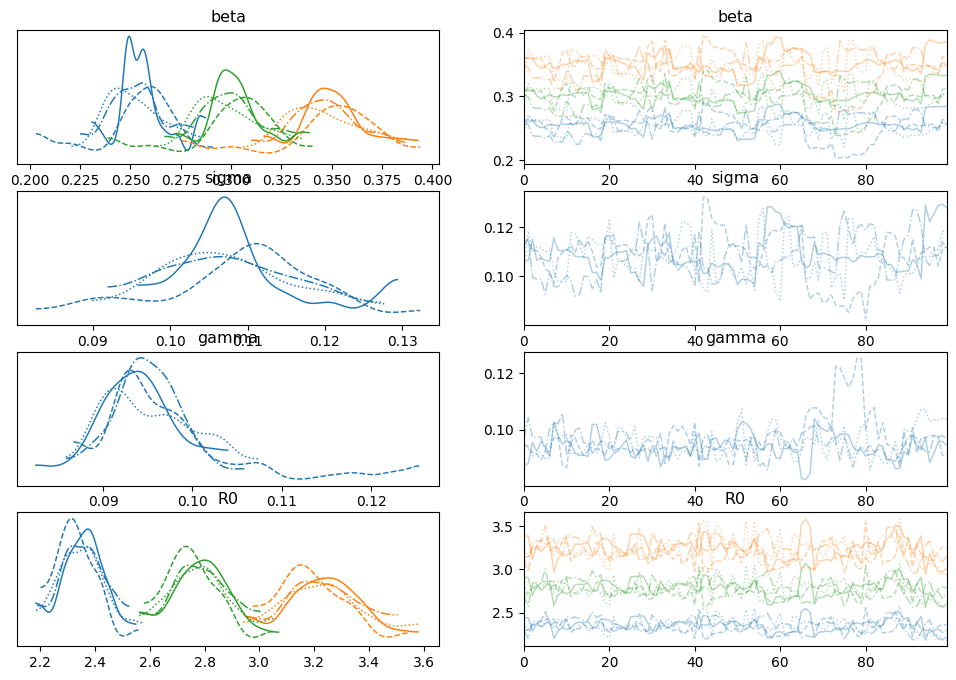

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

In [ ]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame
parameters = ["beta[1]","beta[2]", "beta[3]", 
              "sigma", "recovery_time",
                "gamma", "incubation_period", 
                "R0[1]","R0[2]", "R0[3]",
                  "phi"]

beta = np.array([0.3, 0.4, 0.35])  # Transmission rate (R0 = beta/gamma)
sigma = 1/10         # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/7         # 1/infectious period (Ebola: ~7 days)
phi = 10            # Negative binomial dispersion parameter
reporting_rate = 0.8
r = beta/gamma
rec = 1.0/sigma
incu = 1.0 / gamma

t = {
    'beta[1]': beta[0],
    'beta[2]': beta[1],
    'beta[3]': beta[2],
    'sigma': 1/10,   
    'gamma': 1/7,
    'phi': 10 ,
    'reporting_rate':0.8,
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time':rec,
    'incubation_period': incu}

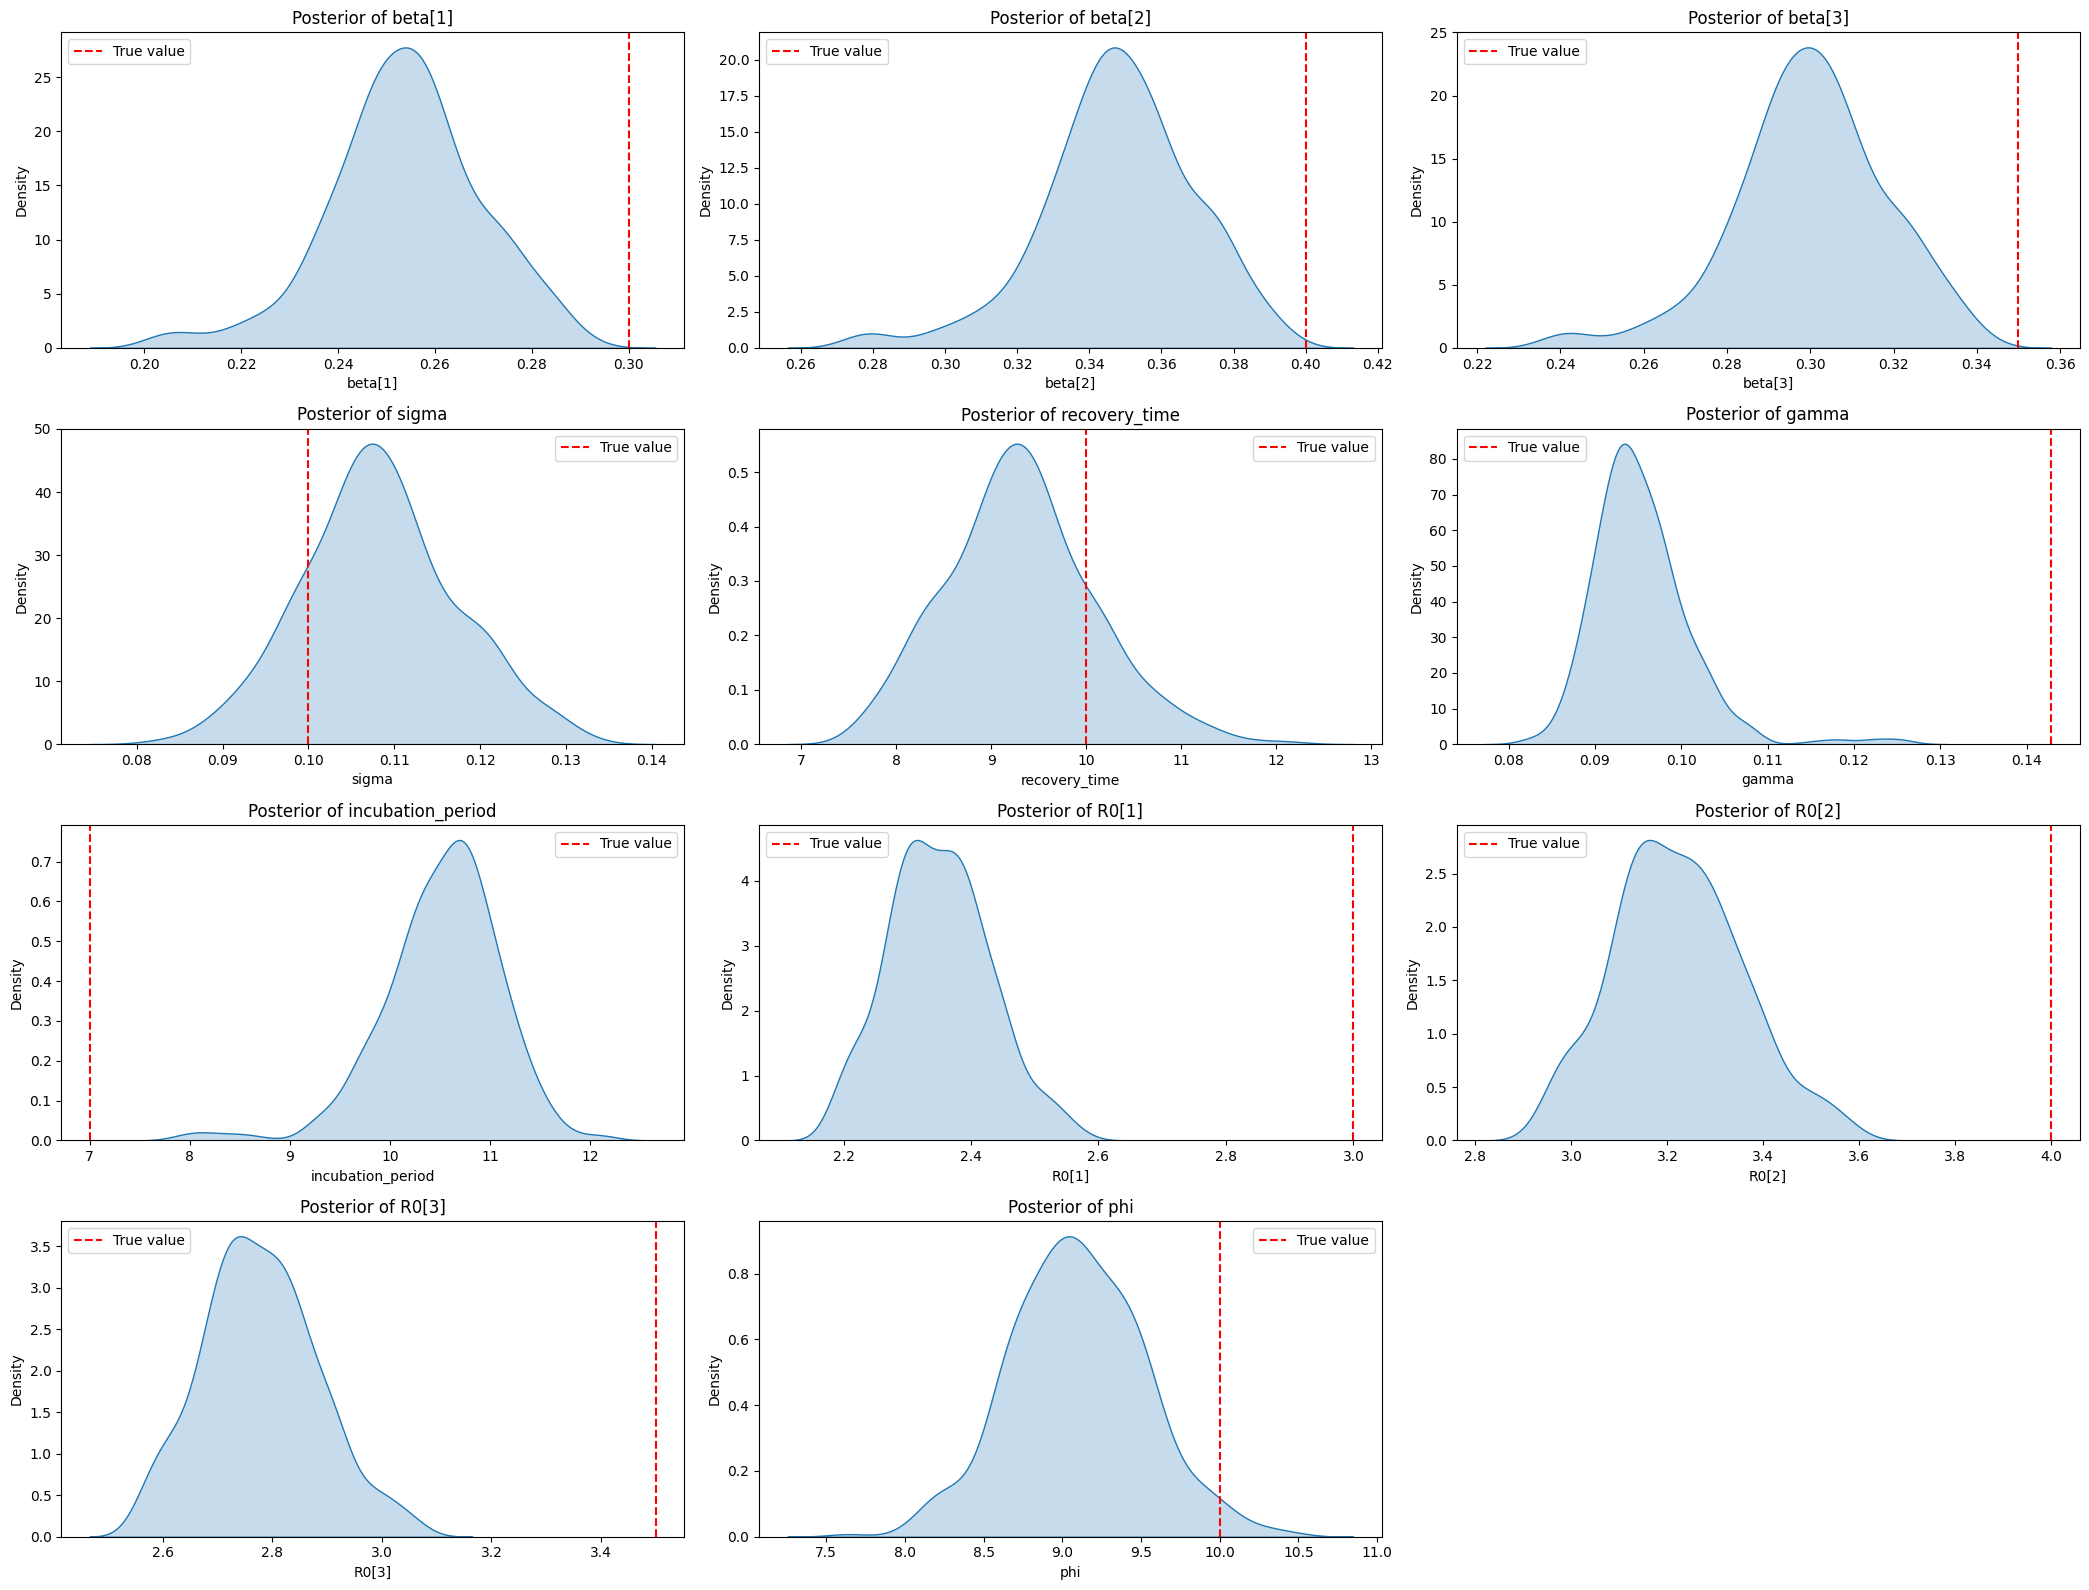

In [ ]:
plot_posterior_kde_grid(fit_multi_model, parameters=parameters, 
                        n_rows=3, n_cols=3, true_values=t)

In [ ]:

# N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# # Set the population size

# # Define initial conditions
# g0 = [N[0]-1000, 0, 1000, 0, 1000]
# l0 = [N[1]-1000, 0, 100, 0, 100]
# s0 = [N[2]-1000, 0, 100, 0, 100]

# ts2 = noisy_cases.values.T
# y0 = [g0, l0, s0]

# # Make the data struture
# seir_data2 = {
#     'N_countries': 3,
#     "n_days": len(ts2[0]),
#     'y0': y0,
#     't0': 0,
#     "t": np.arange(1, len(ts2[0])+1),
#     "N": N.astype(int),
#     "cases": ts2,
# }

# multi_model_weekly = CmdStanModel(stan_file = 'stan files/mult.stan')

In [ ]:
# fit_weekly_model = multi_model_weekly.sample(data = seir_data2,
#                                     #  iter_sampling = 1000,
#                                      chains = 4,
#                                      seed = 0)

In [ ]:
#print(fit_weekly_model.diagnose())

In [ ]:
# weekly_summary = fit_weekly_model.summary()
# weekly_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma", "recovery_time",
#                                  "gamma", "incubation_period", "R0[1]","R0[2]", "R0[3]",
#                                    "phi", "phi_inv"), axis=0)
   

In [ ]:

# az.plot_trace(fit_weekly_model, var_names=["beta", "sigma", "gamma", "R0"])
# plt.show()

# R0

from sympy import *
init_printing()